# Recon TAN

## Load correlation matrix

In [1]:
import numpy as np
import polars as pl

In [5]:
corr_matrices = np.load("/mnt/hdd2/homext/wuch/xn2p/run/logs/bulk_exp_meth_nmic_g_mincv2.0_minmi0.6_0.72_log1p_ft16/seed_42/predicted_DeepTAN_20250321024731_NdCYE/correlation_matrix.npz")
featfeat_pheno = corr_matrices["corr_matrix"]
featfeat_pheno_weighted = corr_matrices["corr_weighted"]

In [6]:
print(featfeat_pheno.shape)
print(f"\nMinimum correlation: {np.nanmin(featfeat_pheno)}")
print(f"Maximum correlation: {np.nanmax(featfeat_pheno)}")
print(f"Mean correlation: {np.nanmean(featfeat_pheno)}")
print(f"Median correlation: {np.nanmedian(featfeat_pheno)}")

(13461, 13461)

Minimum correlation: -0.3723873198032379
Maximum correlation: 0.3586302101612091
Mean correlation: 0.008979512378573418
Median correlation: 0.007908148691058159


In [7]:
# Fill NaN values with 0
featfeat_pheno = np.nan_to_num(featfeat_pheno, nan=0.0)
print(f"\nMinimum correlation: {np.min(featfeat_pheno)}")
print(f"Maximum correlation: {np.max(featfeat_pheno)}")


Minimum correlation: -0.3723873198032379
Maximum correlation: 0.3586302101612091


In [8]:
featfeat_pheno_weighted = np.nan_to_num(featfeat_pheno_weighted, nan=0.0)
print(f"\nMinimum correlation: {np.min(featfeat_pheno_weighted)}")
print(f"Maximum correlation: {np.max(featfeat_pheno_weighted)}")


Minimum correlation: -0.28368866443634033
Maximum correlation: 0.2823566496372223


In [ ]:
# featfeat = featfeat_pheno_weighted / featfeat_pheno
featfeat = featfeat_pheno_weighted / np.where(featfeat_pheno != 0, featfeat_pheno, 1)
featfeat[np.isnan(featfeat)] = 0

In [14]:
print(f"\nShape of featfeat: {featfeat.shape}")
print(f"\nMinimum feat relationship: {np.min(featfeat)}")
print(f"Maximum feat relationship: {np.max(featfeat)}")


Shape of featfeat: (13461, 13461)

Minimum feat relationship: 0.0
Maximum feat relationship: 1.0


## Plot histogram of feature relationships

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

<Figure size 640x480 with 0 Axes>

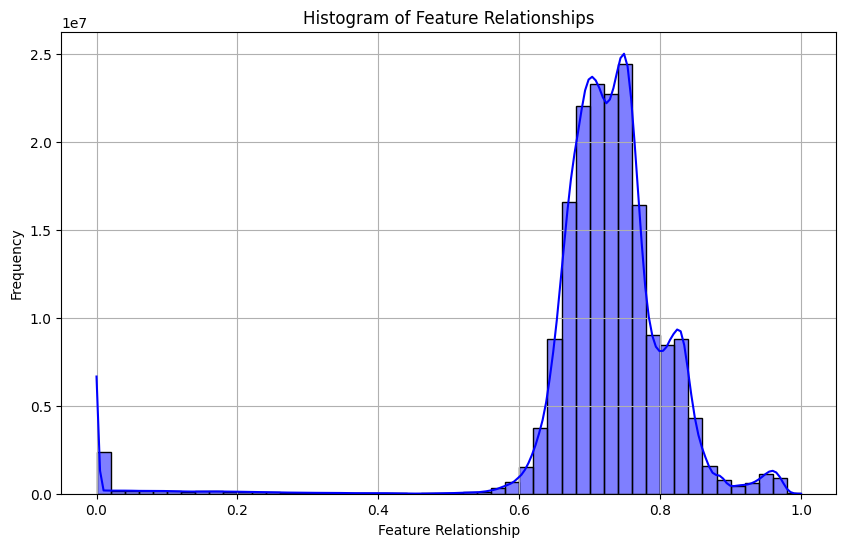

In [16]:
# Try clearing the previous plot if it exists
try:
    plt.clf()
except:
    pass

plt.figure(figsize=(10, 6))
sns.histplot(featfeat.flatten(), bins=50, kde=True, color='blue')
plt.title('Histogram of Feature Relationships')
plt.xlabel('Feature Relationship')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Plot the correlation matrix

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

<Figure size 640x480 with 0 Axes>

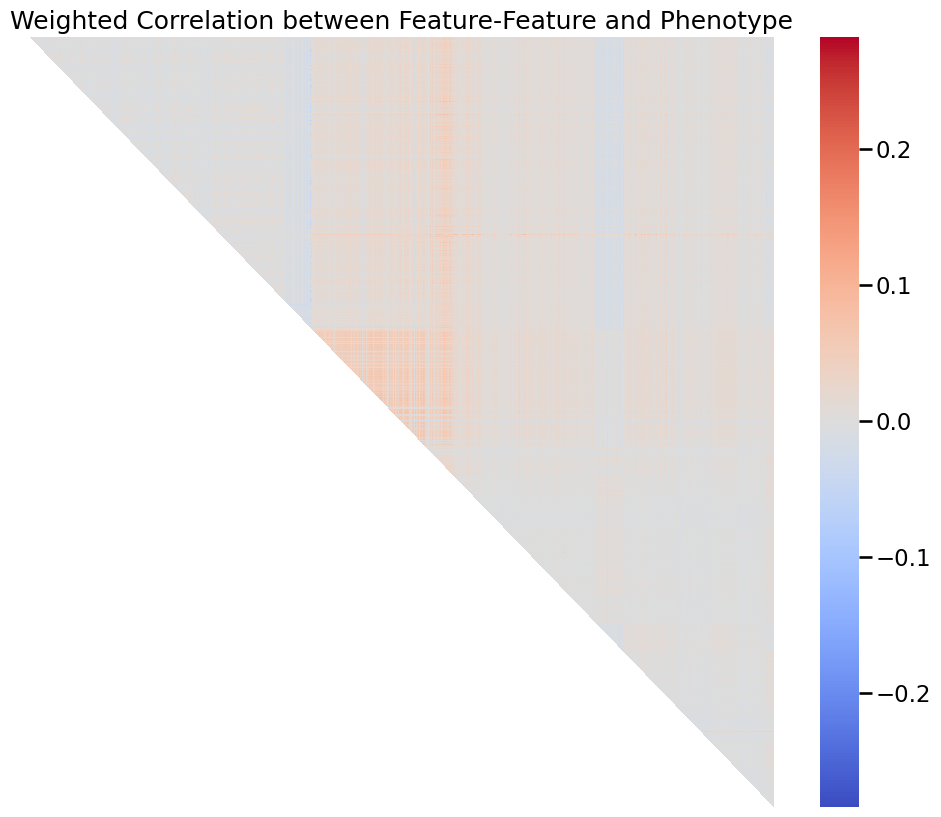

In [37]:
# Try clearing the previous plot if it exists
try:
    plt.clf()
except:
    pass

plt.figure(figsize=(12, 10))
# sns.heatmap(featfeat_pheno, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=feature_names, yticklabels=feature_names)

# Without axis labels for better readability.
# sns.heatmap(featfeat_pheno, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=False, yticklabels=False)

# Clustermap for better visualization of clusters.
# sns.clustermap(featfeat_pheno, cmap='coolwarm')  # , xticklabels=False, yticklabels=False)

# Clustermap with dendrogram, and upper triangle masked, without axis labels.
mask = np.tril(np.ones_like(featfeat_pheno_weighted, dtype=bool))
# sns.clustermap(featfeat_pheno, cmap='coolwarm', mask=mask, xticklabels=False, yticklabels=False)  # , dendrogram_ratio=(.1, .2))  # Adjust dendrogram size if needed. Uncomment to use.
# Failed due to the size of the matrix.

sns.heatmap(featfeat_pheno_weighted, mask=mask, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title('Weighted Correlation between Feature-Feature and Phenotype')
plt.show()